In [3]:
import pandas as pd
df = pd.read_csv('Subject 1.csv', parse_dates=['EventDateTime'])
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11042 entries, 0 to 11041
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   EventDateTime               11042 non-null  datetime64[ns]
 1   DeviceMode                  0 non-null      float64       
 2   BolusType                   593 non-null    object        
 3   Basal                       7419 non-null   float64       
 4   CorrectionDelivered         593 non-null    float64       
 5   TotalBolusInsulinDelivered  593 non-null    float64       
 6   FoodDelivered               593 non-null    float64       
 7   CarbSize                    593 non-null    float64       
 8   CGM                         11042 non-null  int64         
dtypes: datetime64[ns](1), float64(6), int64(1), object(1)
memory usage: 776.5+ KB


In [4]:
df = df.sort_values('EventDateTime')

In [5]:
df['EventDateTime'] = pd.to_datetime(df['EventDateTime'])
df = df.set_index('EventDateTime')

In [6]:
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['day_night'] = df['hour'].apply(lambda x: 0 if (x < 6 or x >= 20) else 1)


In [7]:
import numpy as np

df['hour_sin'] = np.sin(2 * np.pi * df['hour']/24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour']/24)

df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week']/7)
df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week']/7)



In [8]:
df['FoodDelivered'].fillna(0, inplace=True)
df['TotalBolusInsulinDelivered'].fillna(0,inplace=True)

/var/folders/8r/w2tfcf3d63b2dfp05x4fmyx40000gn/T/ipykernel_5462/2558290490.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['FoodDelivered'].fillna(0, inplace=True)
/var/folders/8r/w2tfcf3d63b2dfp05x4fmyx40000gn/T/ipykernel_5462/2558290490.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beha

In [9]:
df = df.drop(columns=['DeviceMode'])

In [10]:
df['BolusType'] = df['BolusType'].fillna('NoBolus')

In [11]:
df = pd.get_dummies(df, columns=['BolusType'], prefix='Bolus')

In [12]:
df['ActiveBolus'] = df['TotalBolusInsulinDelivered'].rolling(window=24, min_periods=1).sum()

In [34]:
df['FoodDelivered'].fillna(0, inplace=True)
df['CarbSize'].fillna(0, inplace=True)
df['TotalBolusInsulinDelivered'].fillna(0, inplace=True)
df['Basal'].fillna(method='ffill', inplace=True)  # берём последнее известное значение
df['CorrectionDelivered'].fillna(0, inplace=True) # можно 0, если логично
df['Basal'].fillna(df['Basal'].mean(), inplace=True)


/var/folders/8r/w2tfcf3d63b2dfp05x4fmyx40000gn/T/ipykernel_5462/412848568.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['FoodDelivered'].fillna(0, inplace=True)
/var/folders/8r/w2tfcf3d63b2dfp05x4fmyx40000gn/T/ipykernel_5462/412848568.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behave

In [35]:
features = [
    'hour_sin', 'hour_cos',
    'day_of_week_sin', 'day_of_week_cos',
    'day_night',
    'FoodDelivered', 'CarbSize',
    'TotalBolusInsulinDelivered', 'Basal', 'CorrectionDelivered',
    'ActiveBolus', 'Bolus_Automatic Bolus/Correction', 'Bolus_BLE Standard Bolus/Correction', 'Bolus_Extended 50.00%/0.00',
    'Bolus_Standard', 'Bolus_Standard/Correction', 'Bolus_NoBolus'
]

target = 'CGM'

In [36]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[features] = scaler.fit_transform(df[features])

import numpy as np

X, y = [], []
window_size = 12  # 12 steps  (1 hour)
for i in range(len(df) - window_size):
    X.append(df[features].iloc[i:i+window_size].values)
    y.append(df[target].iloc[i+window_size])  # target after 1 step forward 

X = np.array(X)
y = np.array(y)

print(X.shape)  
print(y.shape)  

(11030, 12, 17)
(11030,)


In [37]:
import tensorflow as tf
print(tf.__version__)
from tensorflow.keras.models import Sequential

2.16.2


Epoch 1/50


/Users/user/anaconda3/envs/my_cozy_env/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


276/276 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0287 - val_loss: 0.0149
Epoch 2/50
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0148 - val_loss: 0.0133
Epoch 3/50
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0131 - val_loss: 0.0137
Epoch 4/50
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0123 - val_loss: 0.0136
Epoch 5/50
276/276 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0119 - val_loss: 0.0162
Epoch 6/50
276/276 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0117 - val_loss: 0.0127
Epoch 7/50
276/276 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0115 - val_loss: 0.0130
Epoch 8/50
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0114 - val_loss: 0.0128
Epoch 9/50
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0113 - val_loss: 0.0122
Epoch 10/50
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0112 - val_loss: 0.0142
Epoch 11/50
276/276 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0111 - val_loss: 0.0133
Epoch 12/50
276/276 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_4 (GRU)                     │ (None, 32)             │         4,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,789 (57.77 KB)

 Trainable params: 4,929 (19.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 9,860 (38.52 KB)

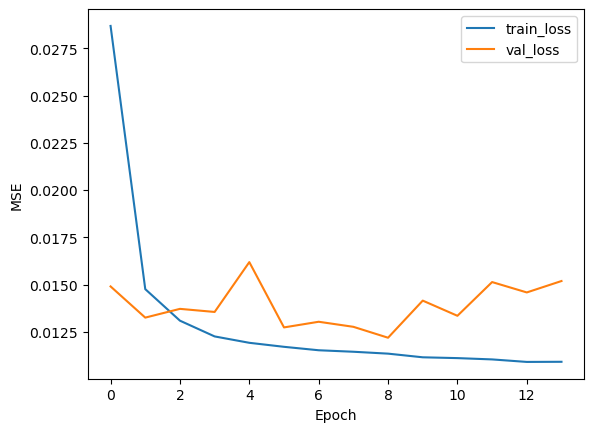

In [38]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt

scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

X_train, X_val, y_train, y_val = train_test_split(
    X, y_scaled, test_size=0.2, shuffle=False  # shuffle=False важно для временных рядов
)

model = Sequential()
model.add(GRU(32, input_shape=(X.shape[1], X.shape[2])))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

model.summary()

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()


69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


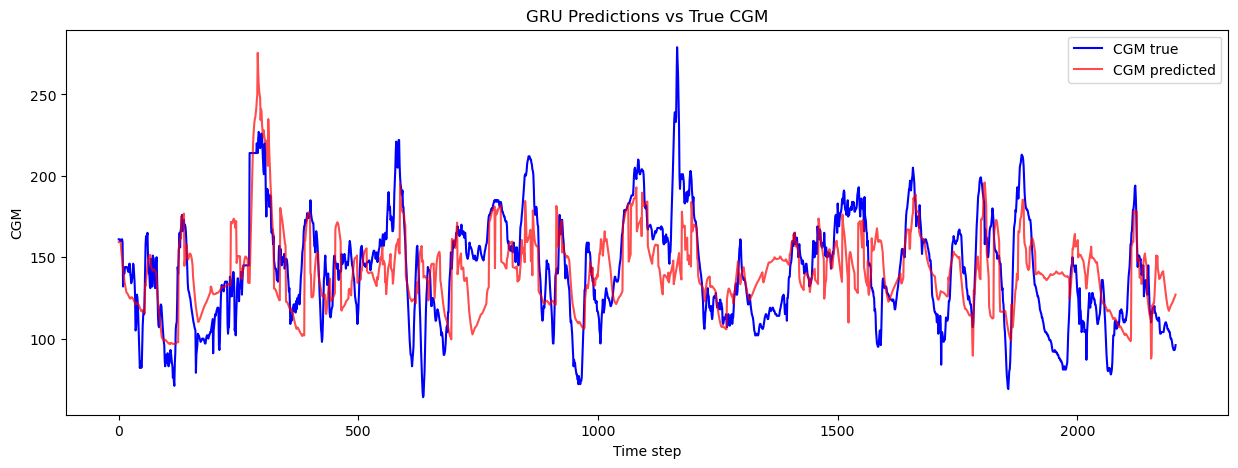

In [40]:

y_pred_scaled = model.predict(X_val)

y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_val)

import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(y_true, label='CGM true', color='blue')
plt.plot(y_pred, label='CGM predicted', color='red', alpha=0.7)
plt.xlabel('Time step')
plt.ylabel('CGM')
plt.title('GRU Predictions vs True CGM')
plt.legend()
plt.show()
